<a href="https://colab.research.google.com/github/smrithi94/PGP_ML_SQL_DATA/blob/main/FoodHubFullCodeSaiSmrithi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 15.0 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.1 which is incompatible.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
tensorflow 2.1

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
food_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
food_df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
print('Rows:',food_df.shape[0], 'Columns:', food_df.shape[1])

Rows: 1898 Columns: 9


#### Observations: There are 1898 Rows and 9 Columns



### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
food_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
The dataset consists of a combination of columns of integer, object and float.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
food_df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations: There are no null values in this case.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here.
df_stats = food_df.describe()
df_stats.loc[['min', 'mean', 'max'], 'food_preparation_time']

,food_preparation_time
min,20.00000
mean,27.37197
max,35.00000


#### Observations:
It takes between 20 to 35 minutes for food to be prepared once an order is placed.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
len(food_df[food_df['rating'] == 'Not given'])

736

#### Observations:
There are 736 orders not rated


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

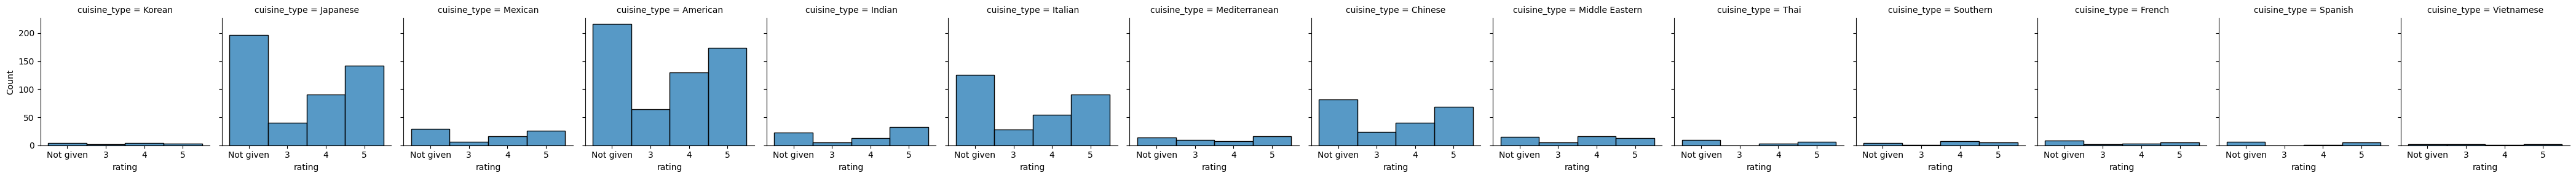

In [ ]:
# Write the code here
import seaborn as sns
sns.FacetGrid(food_df, col='cuisine_type').map(sns.histplot, 'rating')


Observation : After seeing the ratings column, with cuisine type it is observed that the ratings are skewed to the left, there are more high ratings than the low ones. American, Indian and Japanese cuisines are having more orders when compared to the other cuisines.


<Axes: xlabel='cost_of_the_order', ylabel='Count'>

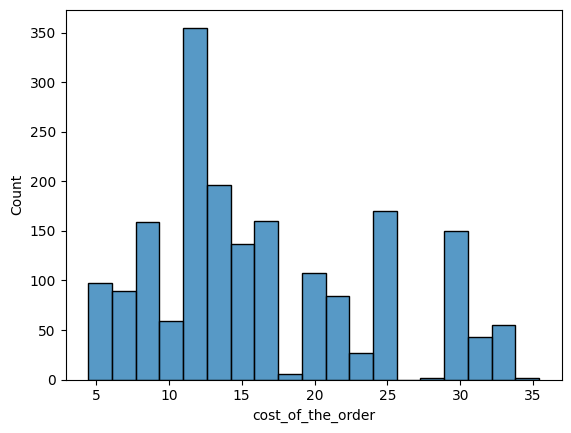

In [ ]:
#Find the distrubuition of the order costs
sns.histplot(data = food_df, x='cost_of_the_order')

Observation: Most of the orders cost between 10 to 30 units


<Axes: xlabel='day_of_the_week', ylabel='count'>

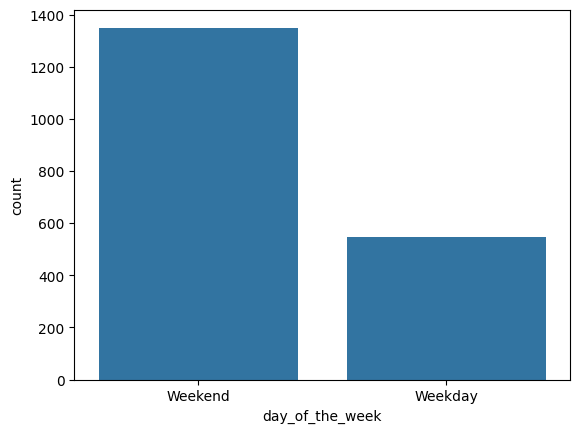

In [ ]:
#seeing the number of orders in the weekdays and weekend
sns.countplot(data = food_df, x='day_of_the_week')

Observations: There are more orders in the weekend compared to the weekdays.


In [ ]:
#Dealing with "Not Given" rows in the ratings column.
food_df['rating'] = food_df['rating'].replace('Not given', pd.NA)
food_df['rating'] = pd.to_numeric(food_df['rating'])
#Looking at the average rating value of a particular cuisine type and filling the value of the "not given" row
food_df['rating'] = food_df.groupby('cuisine_type')['rating'].transform(lambda x: x.fillna(x.mean()))
food_df['rating'] = round(food_df['rating'], 2)

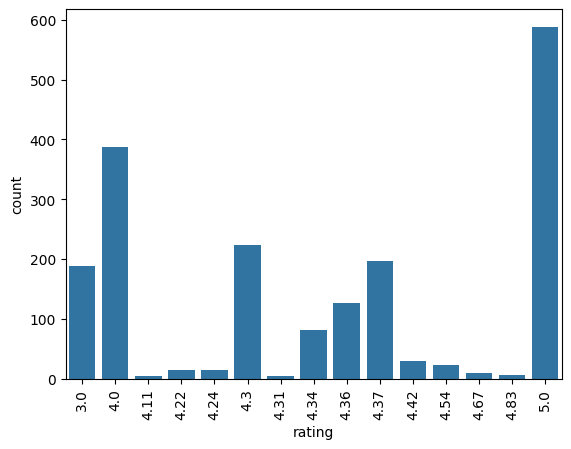

In [ ]:
sns.countplot(data = food_df, x='rating')
plt.xticks(rotation=90)
plt.show()

Observation: After imputing the not rated values with the mean rating of the particular cuisine type, we see that there are more orders having rating 5 and 4.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Write the code here;
food_df['restaurant_name'].value_counts(ascending = False).head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations: Sorting the number of orders received based on the value counts gives us Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, Parm to be the top 5 Restaurants in terms of the orders.



### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
food_df[food_df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().idxmax()

'American'

#### Observations: Filtering and sorting the values on the Cuisine Type gives us that American Cuisine is the most popular one in the weekend.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
round(len(food_df[food_df['cost_of_the_order'] > 20]) / len(food_df) * 100, 2)

29.24

#### Observations: About 30% of orders cost more than 20$


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
print(round(food_df['delivery_time'].mean(),2))

24.16


#### Observations: The average delivery time is 24 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
food_df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:The customers with id 52832, 47440 and 83287 are the top 3 customers.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


<Axes: xlabel='food_preparation_time', ylabel='cost_of_the_order'>

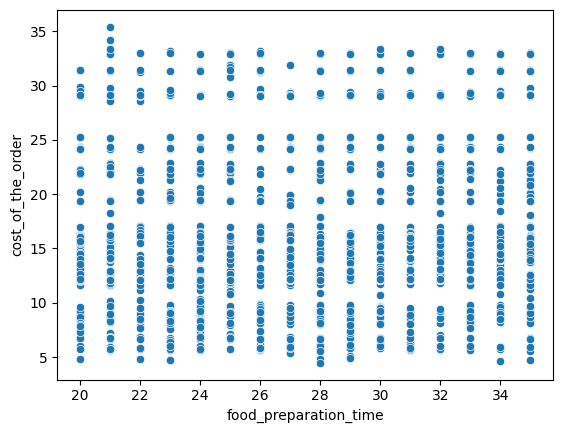

In [ ]:
# Write the code here
sns.scatterplot(data= food_df, x = 'food_preparation_time', y='cost_of_the_order')

Observation: The scatter plot shows minimum correlation of food preparation time and the cost of the order.


<Axes: xlabel='food_preparation_time', ylabel='cost_of_the_order'>

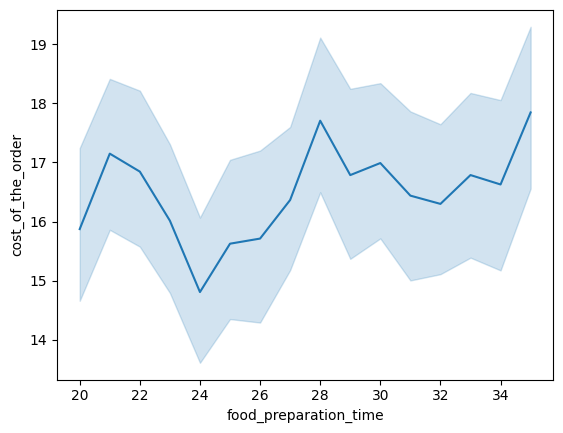

In [ ]:
sns.lineplot(data= food_df, x = 'food_preparation_time', y='cost_of_the_order')

Observation: As food preparation time increases (from 20 to 35 minutes),The cost of the order tends to stay between 15 and 18 units

<Axes: xlabel='delivery_time', ylabel='cost_of_the_order'>

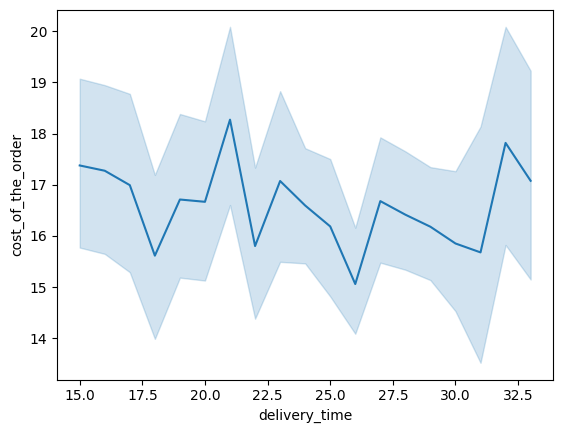

In [ ]:
sns.lineplot(data= food_df, x = 'delivery_time', y='cost_of_the_order')

Observation: The cost of the order seems to decrease slightly as delivery time increases from ~15 mins to ~32 mins.

It's not a smooth trend — there are several zig-zag fluctuations.

<Axes: xlabel='day_of_the_week', ylabel='cost_of_the_order'>

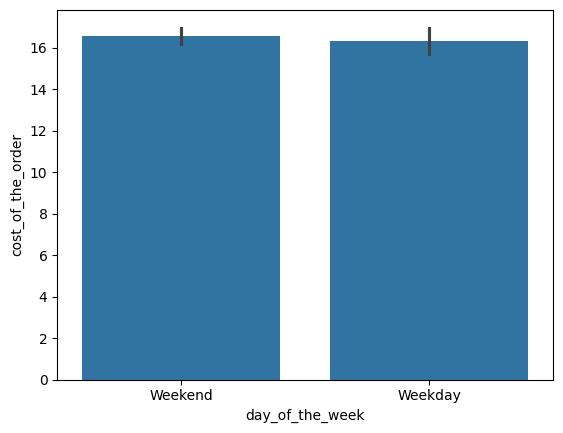

In [ ]:
sns.barplot(data= food_df, x = 'day_of_the_week', y='cost_of_the_order')

Observation : Not Much difference in the cost of the order on weekdays and weekends.

<Axes: xlabel='day_of_the_week', ylabel='delivery_time'>

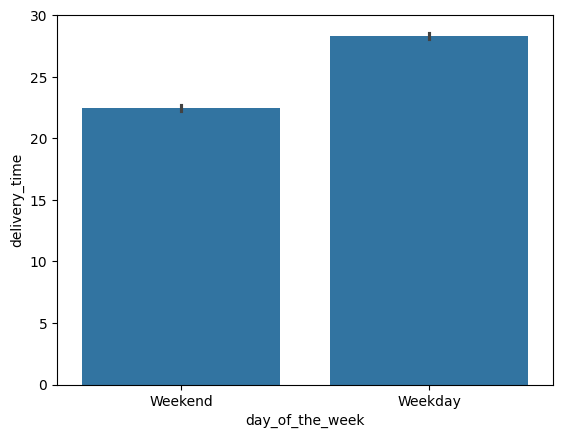

In [ ]:
sns.barplot(data= food_df, x = 'day_of_the_week', y='delivery_time')

Observation - Shows faster delivery trend over the weekends vs the weekdays

<Axes: ylabel='cost_of_the_order'>

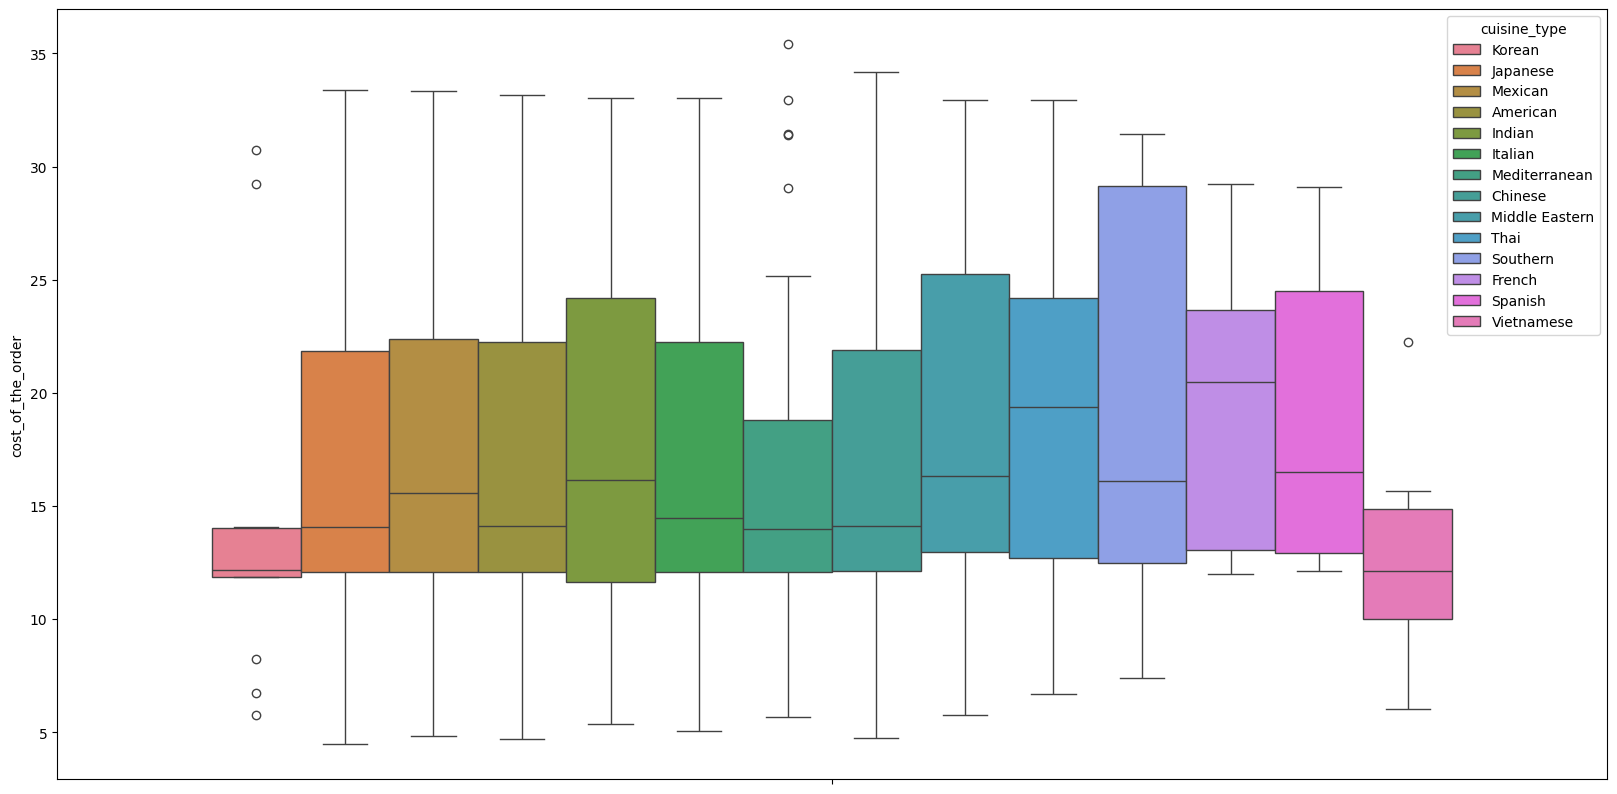

In [ ]:
plt.figure(figsize=(20,10))
sns.boxplot(data = food_df, y='cost_of_the_order', hue ='cuisine_type')

Observation: Some cuisines have higher median costs compared to others.

Southern, French, Spanish cuisines have higher median order costs.

Vietnamese and Korean cuisines have lower median costs.

<Axes: ylabel='delivery_time'>

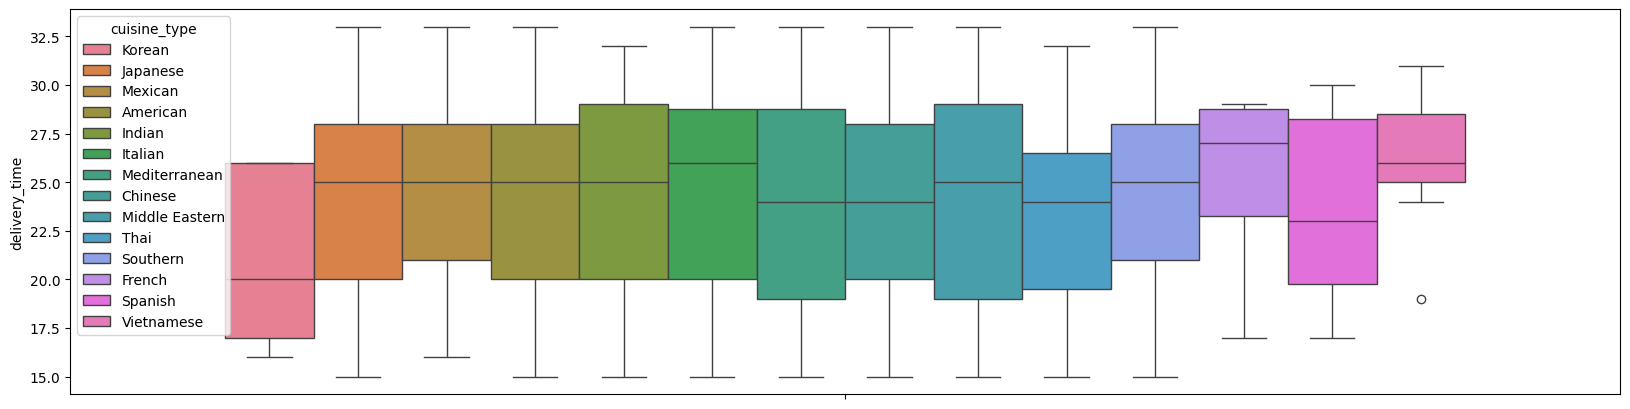

In [ ]:
#Finding the distribution of the delivery time
plt.figure(figsize=(20,5))
sns.boxplot(data = food_df, y='delivery_time', hue = 'cuisine_type')

Observation: Most cuisines have delivery times around 25 minutes.

Korean food is delivered faster.

French, Spanish, Vietnamese are slightly slower.

Very consistent delivery performance across cuisines.



<Axes: ylabel='food_preparation_time'>

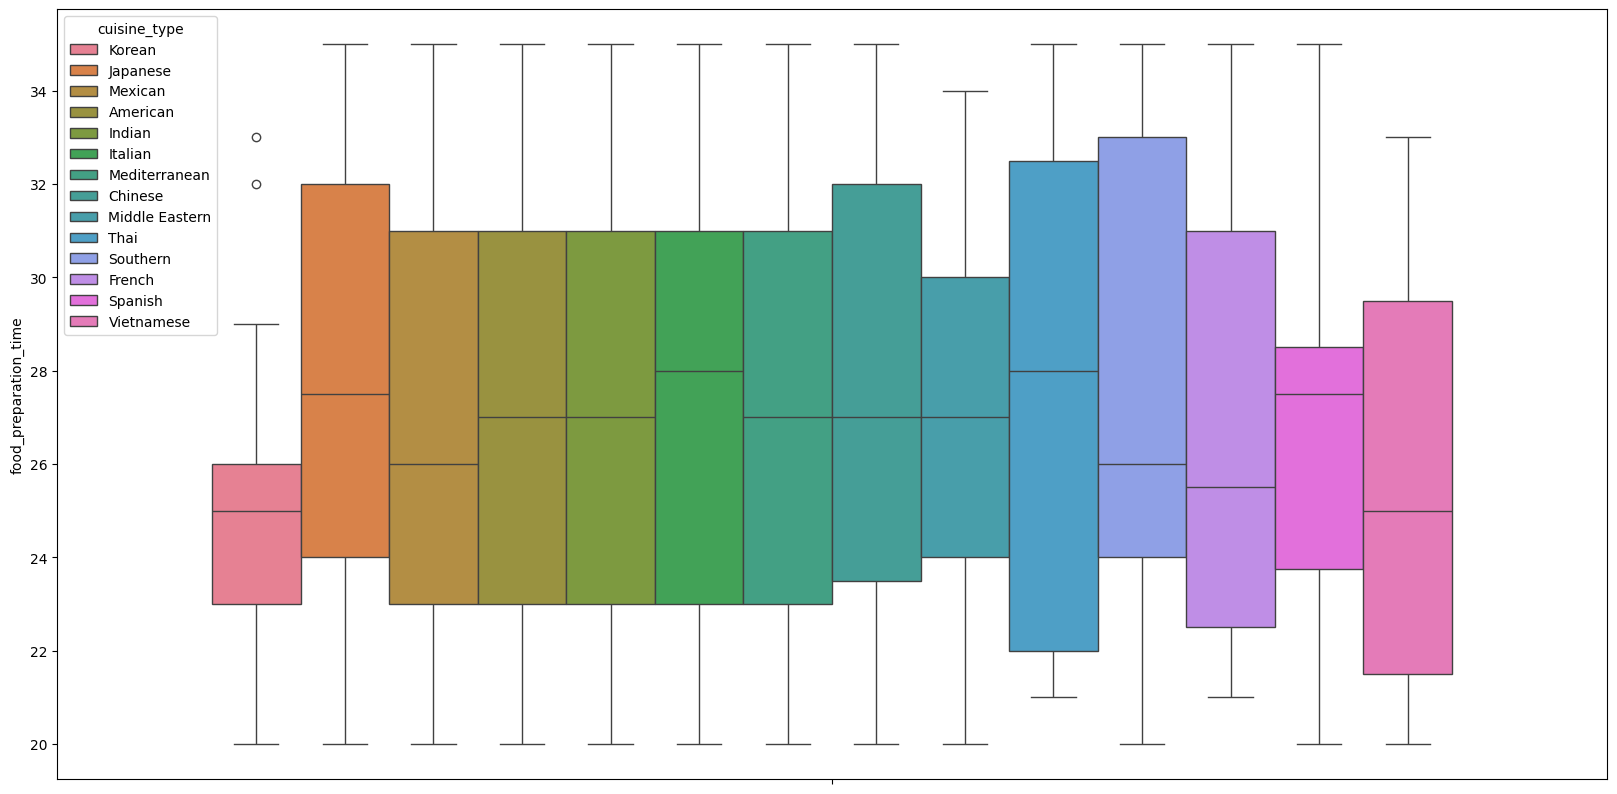

In [ ]:
#Finding the distribution of the food preparation time
plt.figure(figsize=(20,10))
sns.boxplot(data = food_df, y='food_preparation_time', hue = 'cuisine_type')

<Axes: >

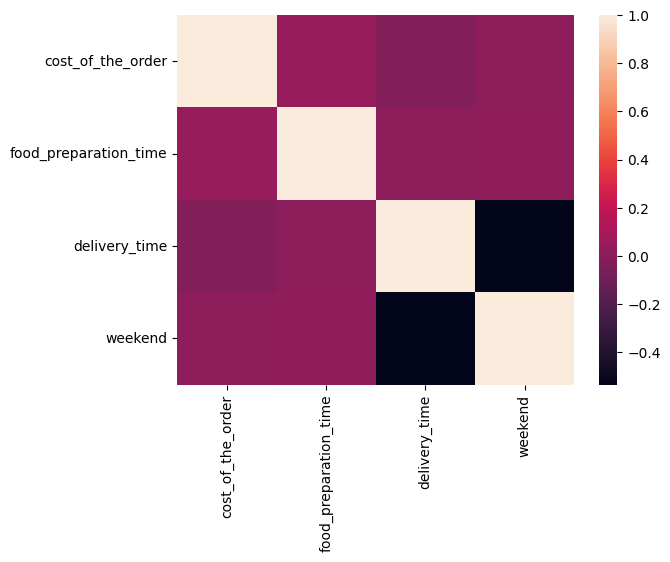

In [ ]:
food_df.columns
food_df['weekend'] = food_df['day_of_the_week'].apply(lambda x: 1 if x == 'Weekend' else 0)
food_df_numeric = food_df[['cost_of_the_order','food_preparation_time','delivery_time', 'weekend']]
sns.heatmap(food_df_numeric.corr())


Observation: Order cost and preparation time/delivery time are almost independent.

High-cost orders do not necessarily take much longer to prepare or deliver.

Deliveries happen faster on weekends (negative correlation).

Maybe because of lower traffic, more drivers available, or fewer office-hour constraints.

Other variables are mostly unrelated.

Weekend doesn’t influence preparation time or cost significantly.

Prep time doesn't very strongly affect delivery time either — though there is a slight trend.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
df_food_top_restaurants = food_df.groupby('restaurant_name').filter(lambda x: x['rating'].count() > 50 and x['rating'].mean() > 4)
df_food_top_restaurants['restaurant_name'].unique()

array(['Blue Ribbon Fried Chicken', 'The Meatball Shop', 'Shake Shack',
       'RedFarm Hudson', 'Blue Ribbon Sushi', 'Parm', 'RedFarm Broadway'],
      dtype=object)

Observation : Blue Ribbon Fried Chicken
              The Meatball Shop
              Shake Shack
              RedFarm Hudson
              Blue Ribbon Sushi
              Parm
              RedFarm Broadway
These are the eligible restaurants.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
def calculate_revenue(row):
    if row['cost_of_the_order'] > 20:
        return row['cost_of_the_order'] * 0.25
    elif row['cost_of_the_order'] > 5:
        return row['cost_of_the_order'] * 0.15
    else:
        return
food_df['revenue'] = food_df.apply(calculate_revenue, axis=1)
total_revenue = food_df['revenue'].sum()
print(total_revenue)

6166.303


#### Observations:
The Net revenue generated by the company is 6166.303

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
food_df['total_time'] = food_df['food_preparation_time'] + food_df['delivery_time']
round(len(food_df[food_df['total_time'] > 60]) / len(food_df)* 100,2)

10.54

#### Observations:
About 10.5% of the orders take more than 60 minutes to get delivered

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
food_df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations: On an average, the delivery time over the weekdays is more than the delivery times in weekends.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

# Conclusion
Customer satisfaction is high, but a large portion of orders lack feedback ratings.

Premium cuisines like French and Spanish have higher order values but slightly longer delivery times.

Affordable cuisines like Vietnamese and Korean have lower costs and faster deliveries.

Delivery times are generally faster on weekends compared to weekdays.

Very weak correlations between order cost, preparation time, and delivery time.



### Recommendations:

Introduce incentives to encourage customers to leave feedback after orders.

Highlight premium cuisines as "gourmet experiences" to justify longer delivery and higher price.

Promote faster cuisines like Korean and Chinese for time-sensitive customers (e.g., lunch offers).

Launch weekend-exclusive offers to leverage faster weekend deliveries.

Bundle or upsell side dishes with low-cost cuisines to improve average order value.